# Anomaly Context — Field Asset Health Monitor Project

Stage 3 of the pipeline. In the program template this stage is "outliers &
missing"; for this dataset both were settled in stages 1–2 (zero missing,
"outliers" proven machine behavior), so the stage's real content is the
**deeper investigation of the documented failures and the open questions**
(OQ1: digital polarity, OQ2: gaps vs failures), producing the group labels
and comparisons that feature engineering (04) will build on.

Consumes: `sensor_readings.parquet`, `failure_windows.csv` (D10 contract).

In [3]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import pandas as pd
from fahm import preprocessing as pp
from fahm import plotting as pl

cfg = pp.load_config("../configs/config.yaml")
df = pp.load_processed(cfg)
fw = pd.read_csv(cfg["paths"]["failure_windows"],
                 parse_dates=["start", "end", "maintenance"])
gaps = pp.find_gaps(df, cfg)
print(df.shape, "| failures:", len(fw), "| gaps:", len(gaps))

(1516948, 16) | failures: 4 | gaps: 331


## 1. Missing values & outliers — status

Settled in earlier stages, cited here:
- **Missing:** zero across all 16 columns (checks table, stage 1).
- **Outliers:** the extremes are machine behavior, not errors — TP2
  zero-offset is calibration; the DV_pressure 9.8 bar sample is a verified
  maintenance episode (stage 2, Q4). Range checks (D08) guard against
  actual sensor breakage.

No cleaning action required → this notebook investigates *anomalies in
context* instead.

#### Just to have a look in the boxplots to have a visualization:

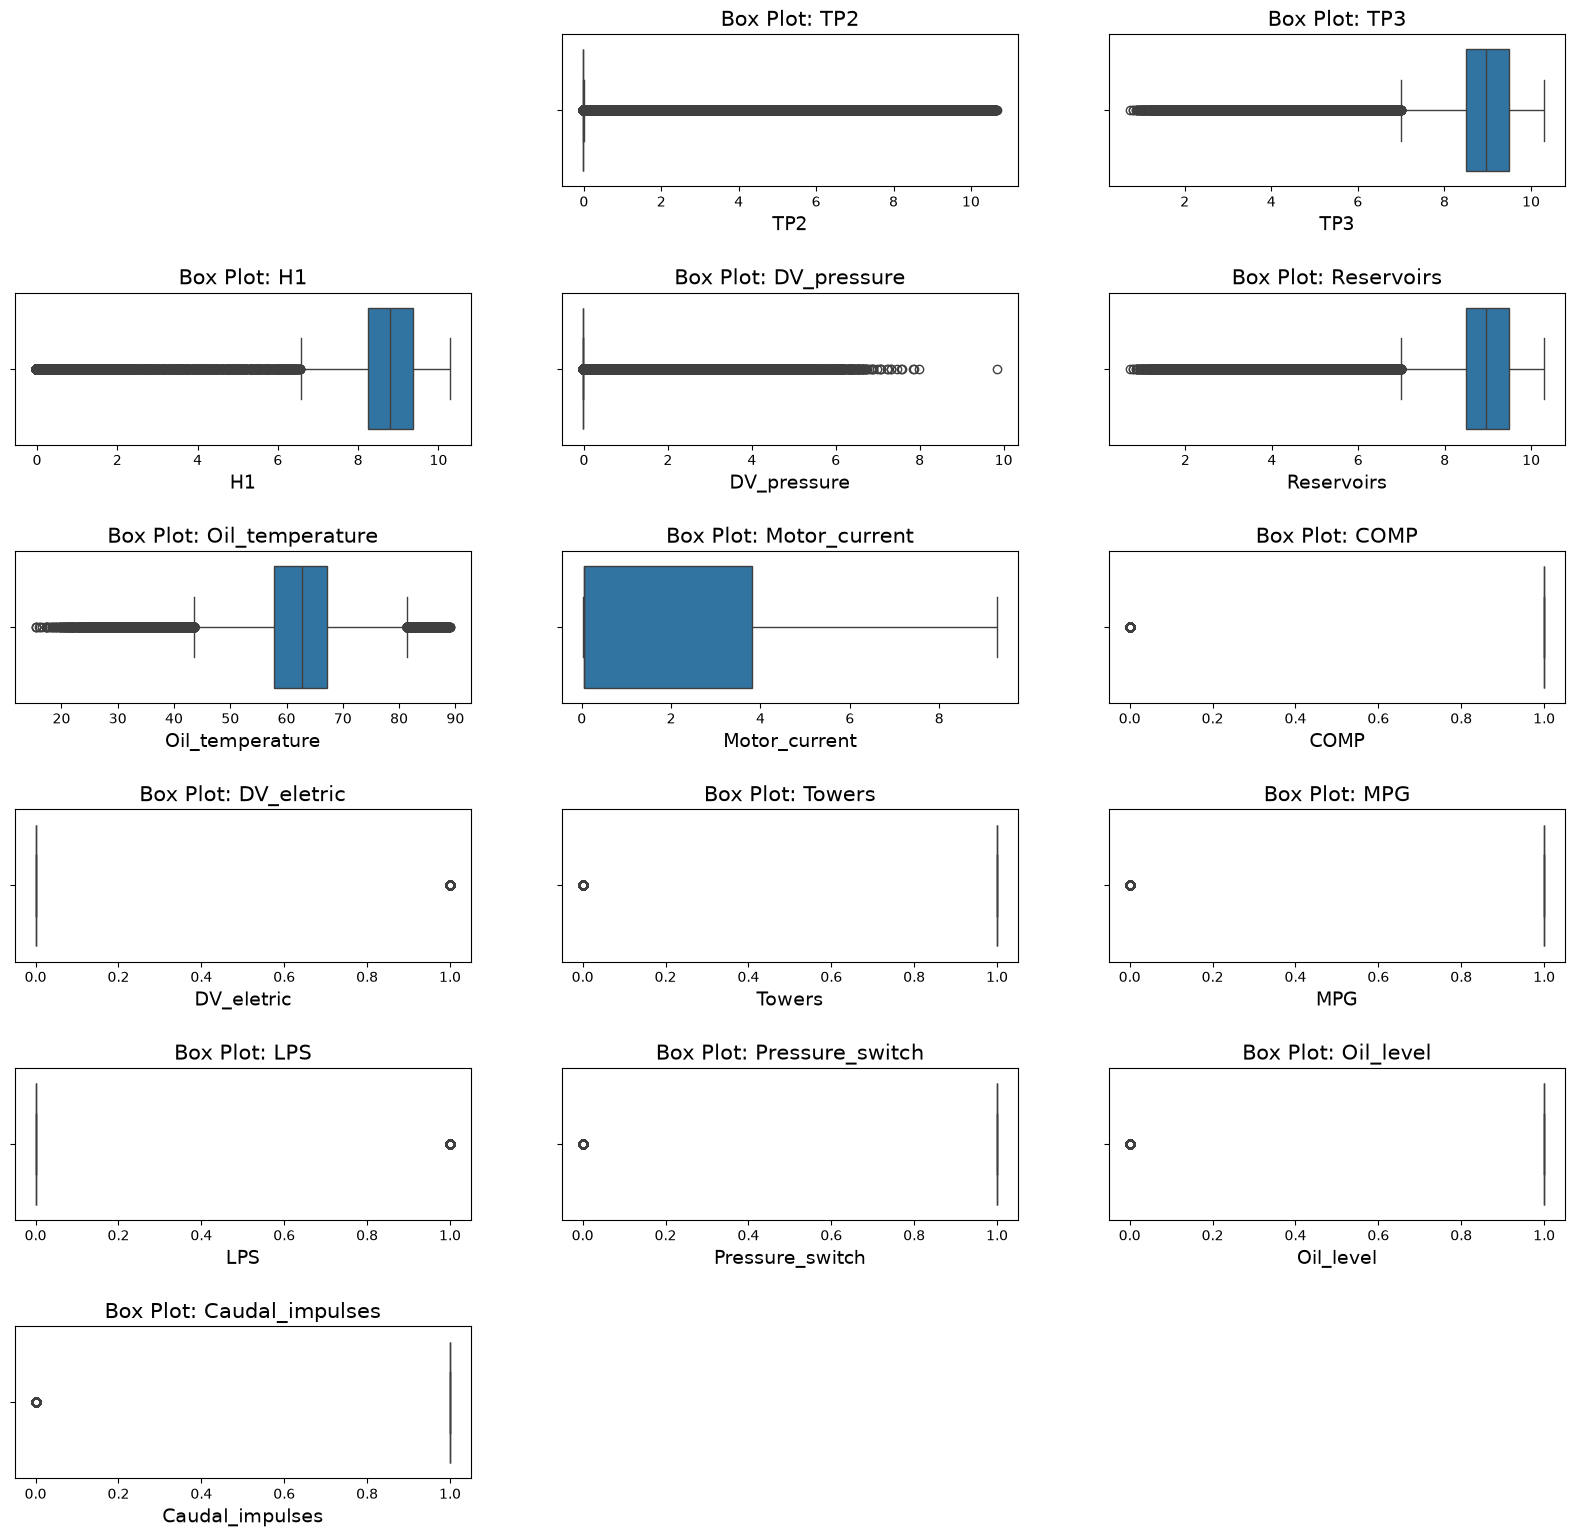

In [4]:
outliers = pl.outliers_boxplot(df)

In [5]:
pl.save_fig(outliers, "outliers_boxplots", cfg)

PosixPath('/home/leoadmin/Documents/GitHub/FAHM_Project/docs/figures/outliers_boxplots.png')

## 2 The four failures, seen in time

One multi-sensor timeline per failure: ±2 days around each window, the key
sensors (TP3, Motor_current, DV_eletric, Oil_temperature), window shaded.
Questions per failure: what changes BEFORE the window (early-warning
evidence)? what does DURING look like (continuous load? faster cycling)?
what happens AFTER (repair signature, gap)?

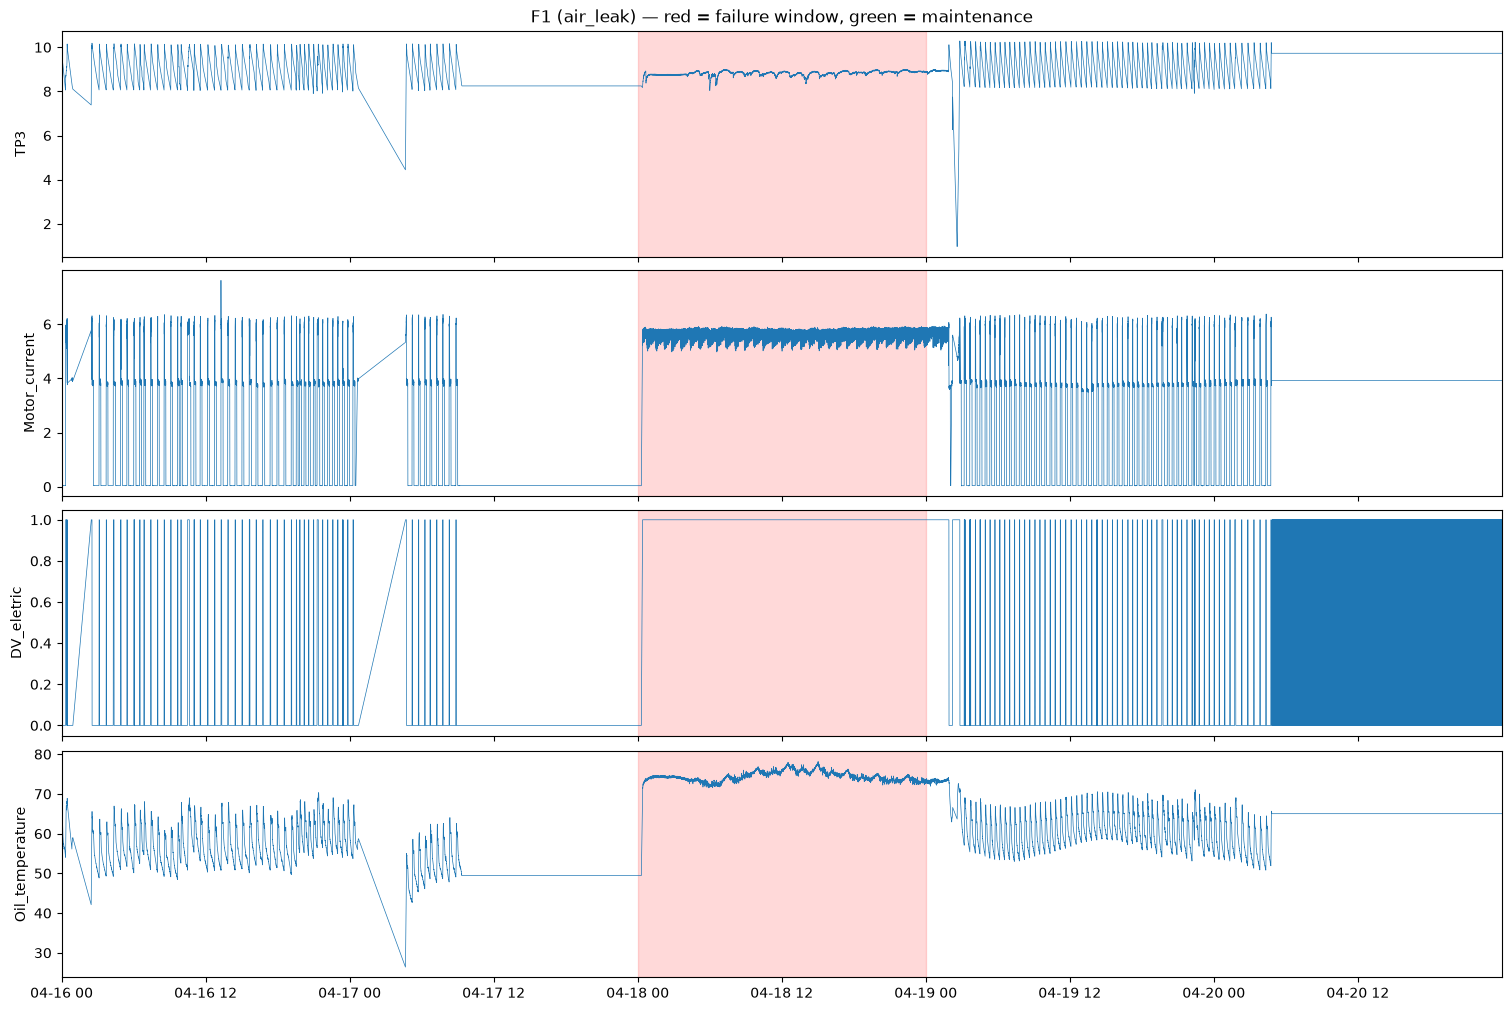

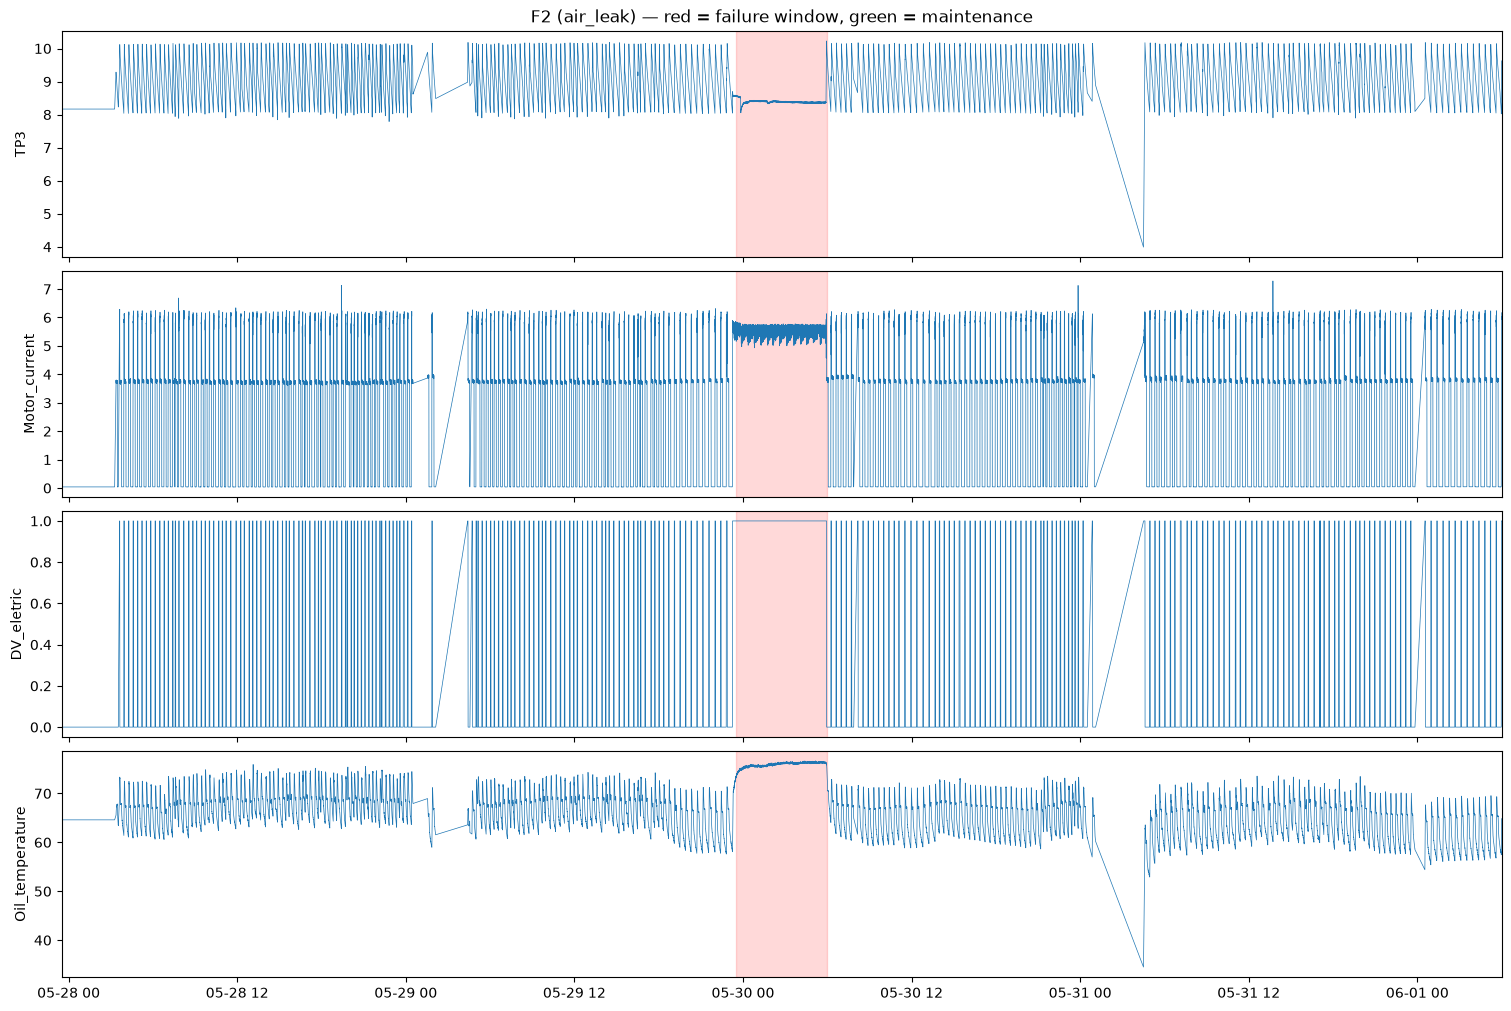

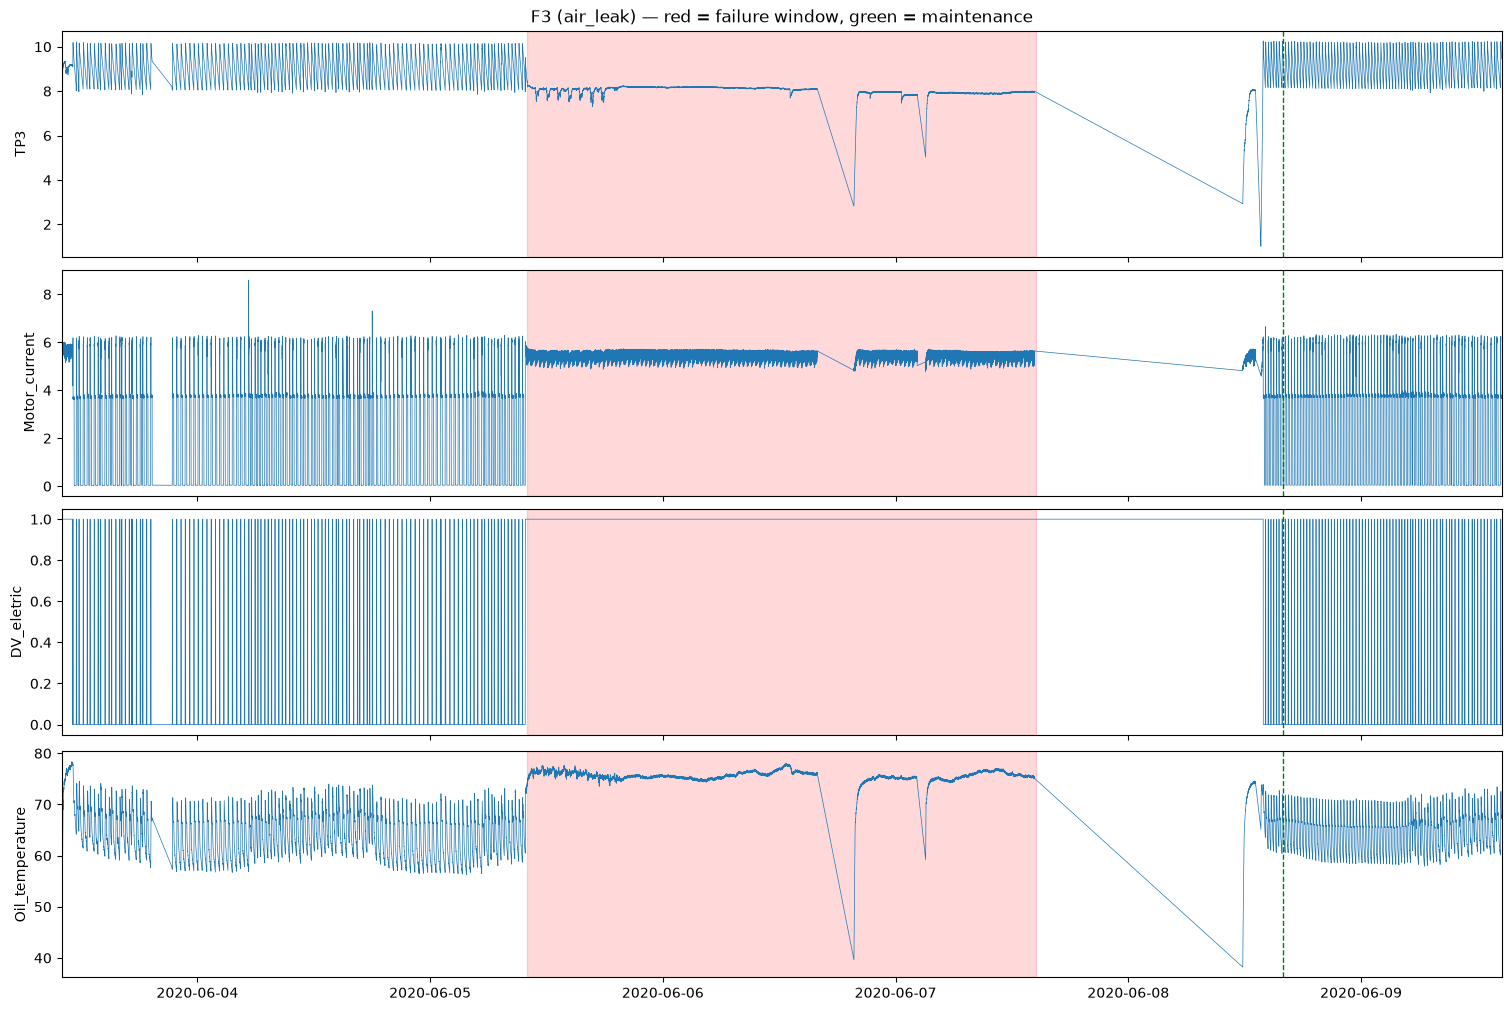

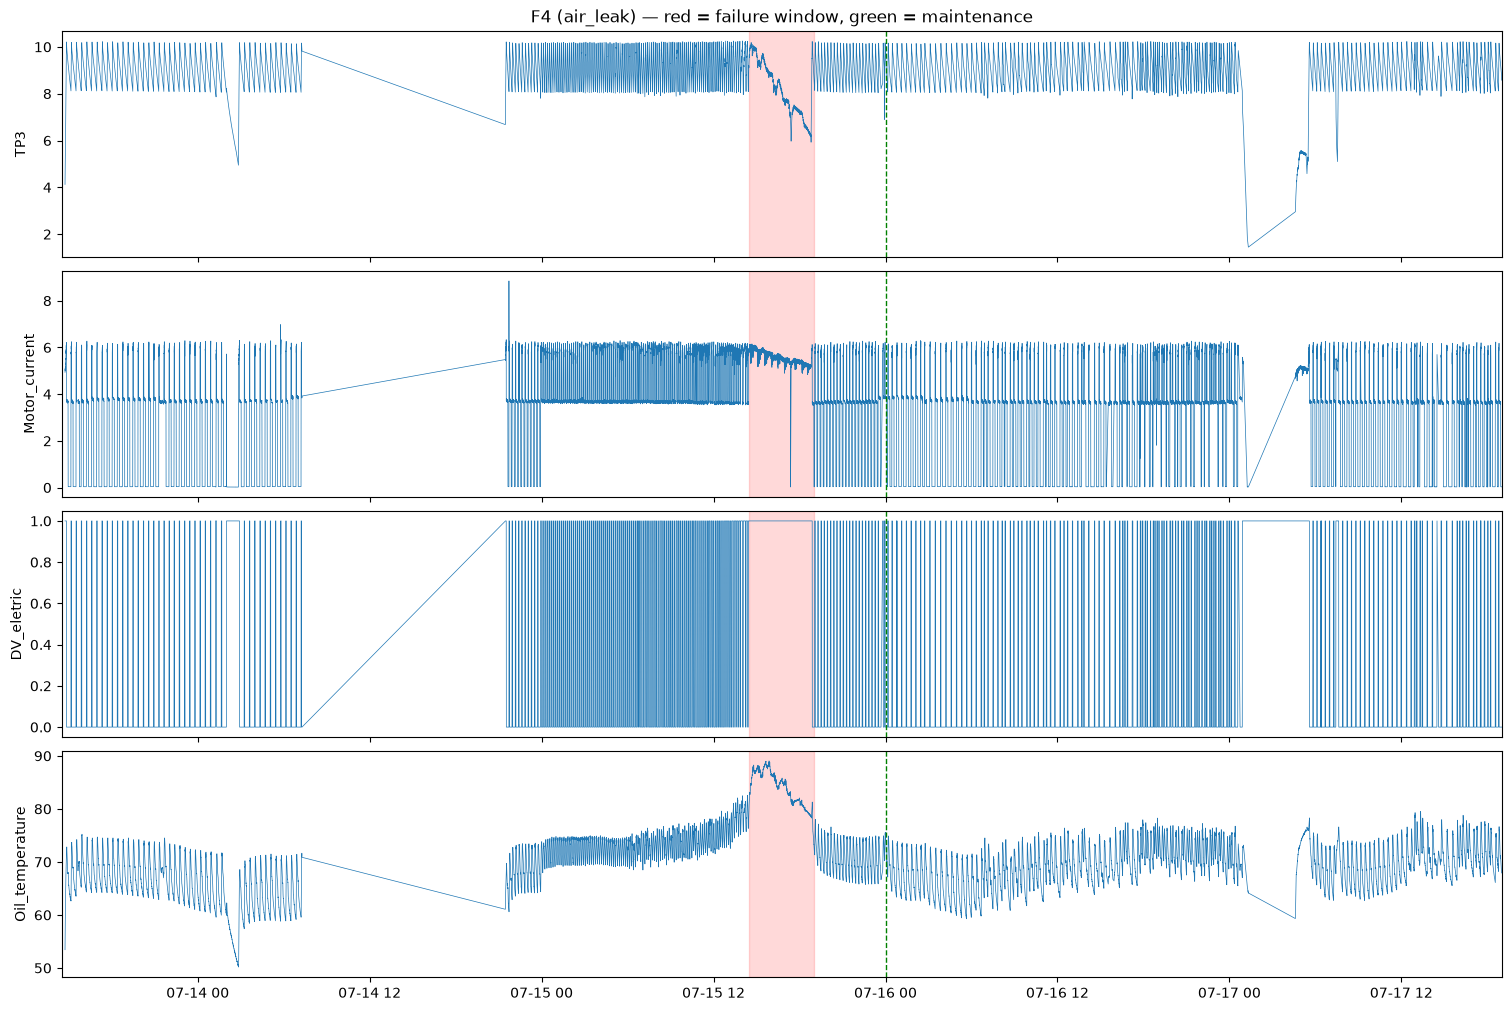

In [6]:
for _, f in fw.iterrows():
    fig = pl.plot_failure_context(df, f, ["TP3", "Motor_current", "DV_eletric", "Oil_temperature"])
    display(fig)
    pl.save_fig(fig, f"failure_context_{f['failure_id']}", cfg)

### Per-failure observations
#### **F1 (Apr 18) —** the catastrophic-leak portrait
- **Before:** healthy cycling through Apr 16-17 morning; then a long RECORDED
  idle flat (~half a day: TP3 pinned 8.2, motor 0, oil cooling to ~49).
  No gradual degradation visible at this zoom before the window — the
  transition looks like a STEP (early-warning implications: check a
  tighter zoom of Apr 17 evening).
- **During (24h window):** motor PINNED ~5.7A, DV_eletric solid 1, TP3
  hovering 8.8-9 never reaching cutoff (~10), oil climbing to high 70s —
  compressor running flat-out and losing to the leak.
- **After:** TP3 crash to ~1 bar just past the window (repair venting), then
  normal cycling, oil running cooler. Maintenance = NaT (no marker, as
  expected).
- **OPEN:** right-edge anomaly Apr 20 ~13:00+ — DV_eletric solid toggling
  block while motor flat ~3.9 and TP3 flat ~9.7. Chatter? test mode?
  gap-bridge artifact? -> investigate (timeline + gap table + COMP).
####  **F2 (May 29-30) —** first read (pre-fix view was axis-crushed)
- **Before:** cycling right up to the window's edge — no long idle flat like F1's. Two failures, two different preludes; that's already a finding (early-warning behavior may differ per event).
- **During (~6.5h):** same catastrophic family as F1 — motor pinned ~5.6A, DV_eletric solid 1, oil jumping to ~75+ — but look at TP3: flat at ~8.3–8.4, notably lower than F1's 8.8–9. The compressor couldn't even hold 8.5 bar. By that measure this leak was worse than F1's, just shorter-lived.
- **After — and here's the puzzle:** at the window's end (~06:00), the machine simply... resumes normal cycling. No repair signature at the boundary — no venting, no gap, no test pattern. So what ended a leak severe enough to pin the motor for six hours? Then, a full day later (May 31 early morning, flanked by what look like bridged gaps — verify against the gap table), comes the deep plunge: TP3 to ~4, oil to ~35 — that looks like the actual repair/depressurization.
-  **Open** - was May 30 (between window-end and the plunge) actually healthy, or still leaking? Three duty 


#### 

In [7]:
for name, lo, hi in [("pre (May 28)", "2020-05-28", "2020-05-29"),
                     ("between (May 30 06:00→)", "2020-05-30 06:00", "2020-05-31"),
                     ("post-plunge (Jun 1)", "2020-06-01", "2020-06-02")]:
    m = (df[pp.TIMESTAMP] >= pd.Timestamp(lo)) & (df[pp.TIMESTAMP] < pd.Timestamp(hi))
    print(f"{name}: duty = {df.loc[m, 'DV_eletric'].mean():.3f}")

pre (May 28): duty = 0.129
between (May 30 06:00→): duty = 0.115
post-plunge (Jun 1): duty = 0.149


#### **F3 (Jun 5–7) — the intervened failure.**
- **Before:** normal cycling up to the window edge; no obvious precursor at this zoom.
- **During (~52h, longest window):** pinned-motor family — motor ~5.3–5.5A (slightly lower than F1/F2's ~5.7), DV_eletric solid, TP3 holding ~8, oil ~75. Distinctive: two deep dips inside the window (TP3 → ~3 and ~5, oil → ~40) — depressurization events during the failure, reading as intervention attempts before the final repair.
- **After:** recording stops ~11 min before the documented window end (the 1,288-min gap from the inventory — verified) — the unit went offline for repair. Recovery on Jun 8: venting spike (TP3 → ~1), then normal cycling resuming almost exactly at the green maintenance marker (Jun 8 16:00) — the only failure where documented maintenance and physical recovery visibly agree.


#### **F4 (Jul 15) — the gradual failure, and the different species.**
- **Before:** the precursor F1–F3 lack — from late Jul 14, cycling densifies (DV_eletric nearly solid, motor dwelling at 6A) and oil temperature ramps steadily ~70 → ~89 for hours into the window. Visible degradation in advance.
- **During (~4.5h, shortest window):** not a plateau but a losing battle — TP3 declining progressively 10 → 6 while the motor stays pinned; oil peaking ~89, the hottest reading of the dataset.
- **After:** cycling resumes at window end; the maintenance marker (Jul 16 00:00) shows no physical signature at all — plain cycling straight through it — while a clear depressurization/repair event appears ~Jul 17 early morning. Documented maintenance date and physical repair disagree (opposite of F3).

### **Cross-failure synthesis - The four failures are not one phenomenon.** 
**During:** F1/F2/F3 are plateau-type (motor pinned, TP3 holding a losing level); F4 is decline-type (TP3 progressively falling). **Before:** F1 — long idle then a step; F2 — nothing visible; F3 — nothing obvious at this zoom; F4 — hours of visible degradation (duty densification + oil ramp). **After:** repair signatures align with documented maintenance only for F3; F2's ended undocumented; F4's marker has no signature but a repair appears a day later. **Consequence:** early-warning capability will be heterogeneous across failures — F4 promises real advance signal, F1/F2 may offer little — and documented windows/maintenance dates are approximate human records that the sensors can and do audit.

## 3 Episode questions

## 4. OQ2 — gaps vs failures

Exhibit A (found in stage 1's inventory): a 1,288-min gap starts
**2020-06-07 14:19** — 11 minutes before F3's documented end (14:30) — and
recording resumes the morning of F3's maintenance day. Recording stops
around repairs.

Systematic test: for every failure, list gaps that start/end within ± N
days of the window; and separately, does every LARGE gap sit near a
failure/maintenance date, or do unexplained ones remain (candidates for
undocumented events, like the Apr 6 episode)?

In [8]:
# TODO: small analysis (notebook-level is fine, promote to src if reused):
# for each fw row: gaps[(gaps.gap_start > f.start - pd.Timedelta(days=3)) &
#                        (gaps.gap_end   < f.end   + pd.Timedelta(days=3))]
# then the reverse: top-10 gaps -> nearest failure/maintenance distance

### OQ2 verdict
<gaps cluster around failures: yes/no/partially; unexplained large gaps: ...;
consequence for features (post-gap warm-up rule?): ...>

## 5. OQ1 — digital polarity (Oil_level, Pressure_switch)

Both are "active" ~90-99% of the time despite docs saying active = fault /
event. Test: WHEN does the inactive time occur?

In [9]:
# inactive_ts = df.loc[df["Oil_level"] == 0, "timestamp"]
# 1) daily counts over the whole record (bar/line) with failure windows shaded
# 2) fraction of inactive time inside failure windows ± 1 day vs outside
# same for Pressure_switch

### OQ1 verdict
<clustered around failures/maintenance/gaps -> polarity/behavior story;
scattered -> revisit. Sensor-table meaning updated accordingly.>

## 6. Healthy vs pre-failure groups (the t-test, adapted)

Program recipe: t-test features across target classes. Adapted here (D13):
rows are labeled from `fw` (healthy / pre-failure / in-failure /
post-repair), groups compared by **effect size and distribution overlap**,
not p-values — 10s samples are heavily autocorrelated, so classic
significance is meaningless at n=1.5M; rank-based stats (Mann-Whitney) may
be reported as descriptive only. The REAL significance test is the model's
early-warning evaluation later.

In [10]:
# TODO: labeling helper in src (this one WILL be reused by stage 4):
# def label_windows(df, fw, prefail_hours=48, postrepair_hours=12) -> pd.Series
#   categories: healthy / prefail / infail / postrepair
# labels = pp.label_windows(df, fw)
# labels.value_counts()

In [11]:
# comparison per key sensor (Oil_temperature, Motor_current, TP3, DV_eletric):
# side-by-side hists or .groupby(labels).describe() ; effect size =
# (median_prefail - median_healthy) / IQR_healthy  (robust, state-mixture friendly)

### Group-comparison findings
<which sensors shift before failure, by how much — this is the
early-warning-detectability evidence stage 4 builds features from>

## Findings feed-forward
- **To 04 (features):** label_windows() helper; sensors with pre-failure
  shift: <...>; post-gap warm-up rule: <needed/not, from OQ2>.
- **Sensor table updates:** Oil_level / Pressure_switch meaning: <from OQ1>.
- **Open items:** <anything unresolved>